<a href="https://colab.research.google.com/github/the-star-boy/Local-repo/blob/main/Z_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('placement.csv')

In [13]:
df.sample(4)

,cgpa,placement_exam_marks,placed
320,7.18,51.0,1
253,6.98,76.0,0
118,6.90,54.0,0
21,7.43,33.0,1


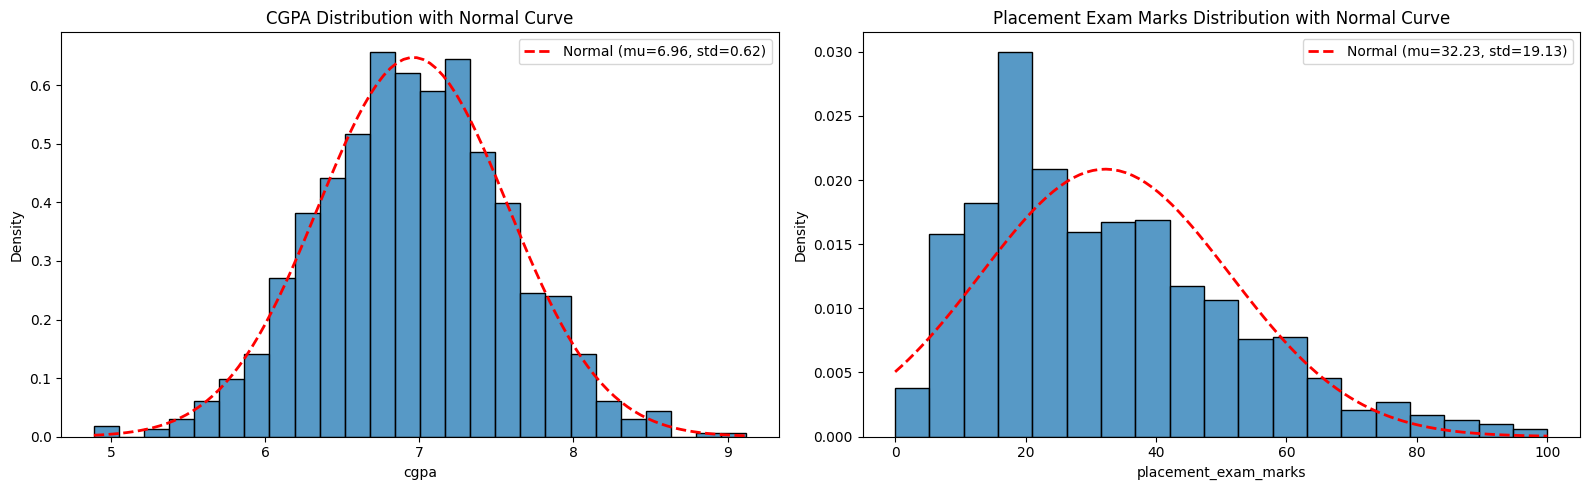

In [23]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot for 'cgpa'
sns.histplot(df['cgpa'], ax=axes[0], stat='density', kde=False)
mu_cgpa, std_cgpa = df['cgpa'].mean(), df['cgpa'].std()
x_cgpa = np.linspace(df['cgpa'].min(), df['cgpa'].max(), 100)
p_cgpa = norm.pdf(x_cgpa, mu_cgpa, std_cgpa)
axes[0].plot(x_cgpa, p_cgpa, color='red', linestyle='dashed', linewidth=2, label=f'Normal (mu={mu_cgpa:.2f}, std={std_cgpa:.2f})')
axes[0].set_title('CGPA Distribution with Normal Curve')
axes[0].legend()

# Plot for 'placement_exam_marks'
sns.histplot(df['placement_exam_marks'], ax=axes[1], stat='density', kde=False)
mu_marks, std_marks = df['placement_exam_marks'].mean(), df['placement_exam_marks'].std()
x_marks = np.linspace(df['placement_exam_marks'].min(), df['placement_exam_marks'].max(), 100)
p_marks = norm.pdf(x_marks, mu_marks, std_marks)
axes[1].plot(x_marks, p_marks, color='red', linestyle='dashed', linewidth=2, label=f'Normal (mu={mu_marks:.2f}, std={std_marks:.2f})')
axes[1].set_title('Placement Exam Marks Distribution with Normal Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
print("Mean val of cgpa",df['cgpa'].mean())
print("Std val of cgpa",df['cgpa'].std())
print("min val of cgpa",df['cgpa'].min())
print("max val of cgpa",df['cgpa'].max())
#

Mean val of cgpa 6.96124
Std val of cgpa 0.6158978751323894
min val of cgpa 4.89
max val of cgpa 9.12


In [53]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: xlabel='placement_exam_marks'>

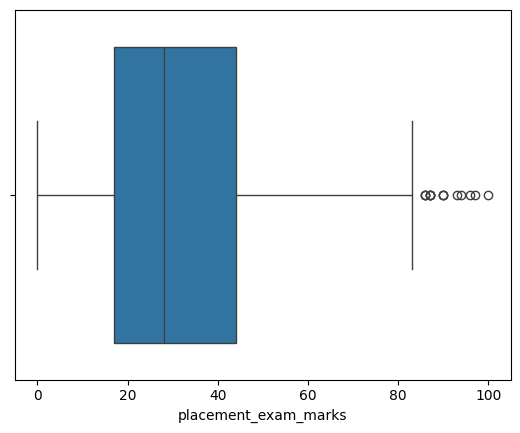

In [58]:
sns.boxplot(x=df['placement_exam_marks'])

In [59]:
#FINDING THE IQR
per25=df['placement_exam_marks'].quantile(0.25)
per75=df['placement_exam_marks'].quantile(0.75)



In [61]:
per75

np.float64(44.0)

In [62]:
iqr=per75-per25

In [63]:
iqr

np.float64(27.0)

In [64]:
upper_limit=per75+1.5*iqr
lower_limit=per25-1.5*iqr

In [65]:
print("upper limit",upper_limit)
print("lower limit",lower_limit)

upper limit 84.5
lower limit -23.5


,cgpa,placement_exam_marks,placed
0,7.190000,26.0,1
1,7.460000,38.0,1
2,7.540000,40.0,1
3,6.420000,8.0,1
4,7.230000,17.0,0
...,...,...,...
995,8.808934,44.0,1
996,8.808934,65.0,1
997,5.113546,34.0,0
998,8.620000,46.0,1


## FINDING **OUTLIERS**

In [81]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed,cgpa_zscore
9,7.75,94.0,1,1.280667
40,6.60,86.0,1,-0.586526
61,7.51,86.0,0,0.890992
134,6.33,93.0,0,-1.024910
162,7.80,90.0,0,1.361849
283,7.09,87.0,0,0.209061
290,8.38,87.0,0,2.303564
311,6.97,87.0,1,0.014223
324,6.64,90.0,0,-0.521580
630,6.56,96.0,1,-0.651472


In [82]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed,cgpa_zscore


# **TRIMMING**

In [72]:
new_df=df[df['placement_exam_marks'] < upper_limit]

In [75]:
new_df.shape

(985, 4)

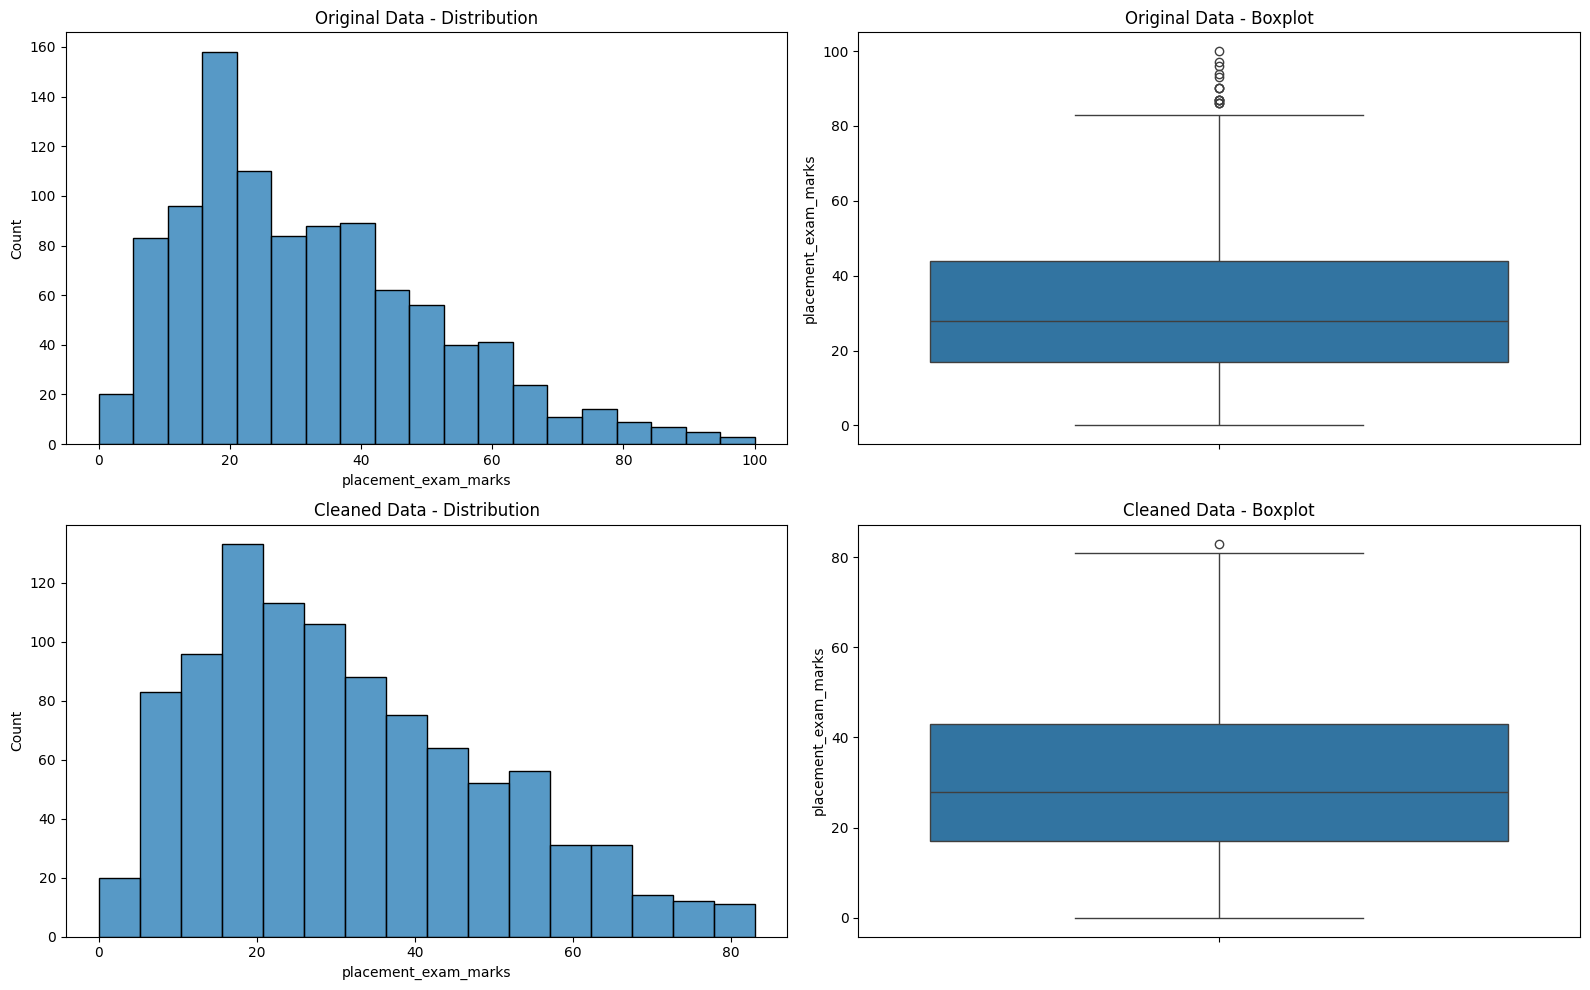

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df['placement_exam_marks'], ax=axes[0, 0])
axes[0, 0].set_title('Original Data - Distribution')

sns.boxplot(df['placement_exam_marks'], ax=axes[0, 1])
axes[0, 1].set_title('Original Data - Boxplot')

sns.histplot(new_df['placement_exam_marks'], ax=axes[1, 0])
axes[1, 0].set_title('Cleaned Data - Distribution')

sns.boxplot(new_df['placement_exam_marks'], ax=axes[1, 1])
axes[1, 1].set_title('Cleaned Data - Boxplot')

plt.tight_layout()
plt.show()

# **CAPPING**

In [86]:
new_df_cap=df.copy()

new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>upper_limit,upper_limit,
    new_df_cap['placement_exam_marks'])

In [87]:
new_df_cap.shape

(1000, 4)

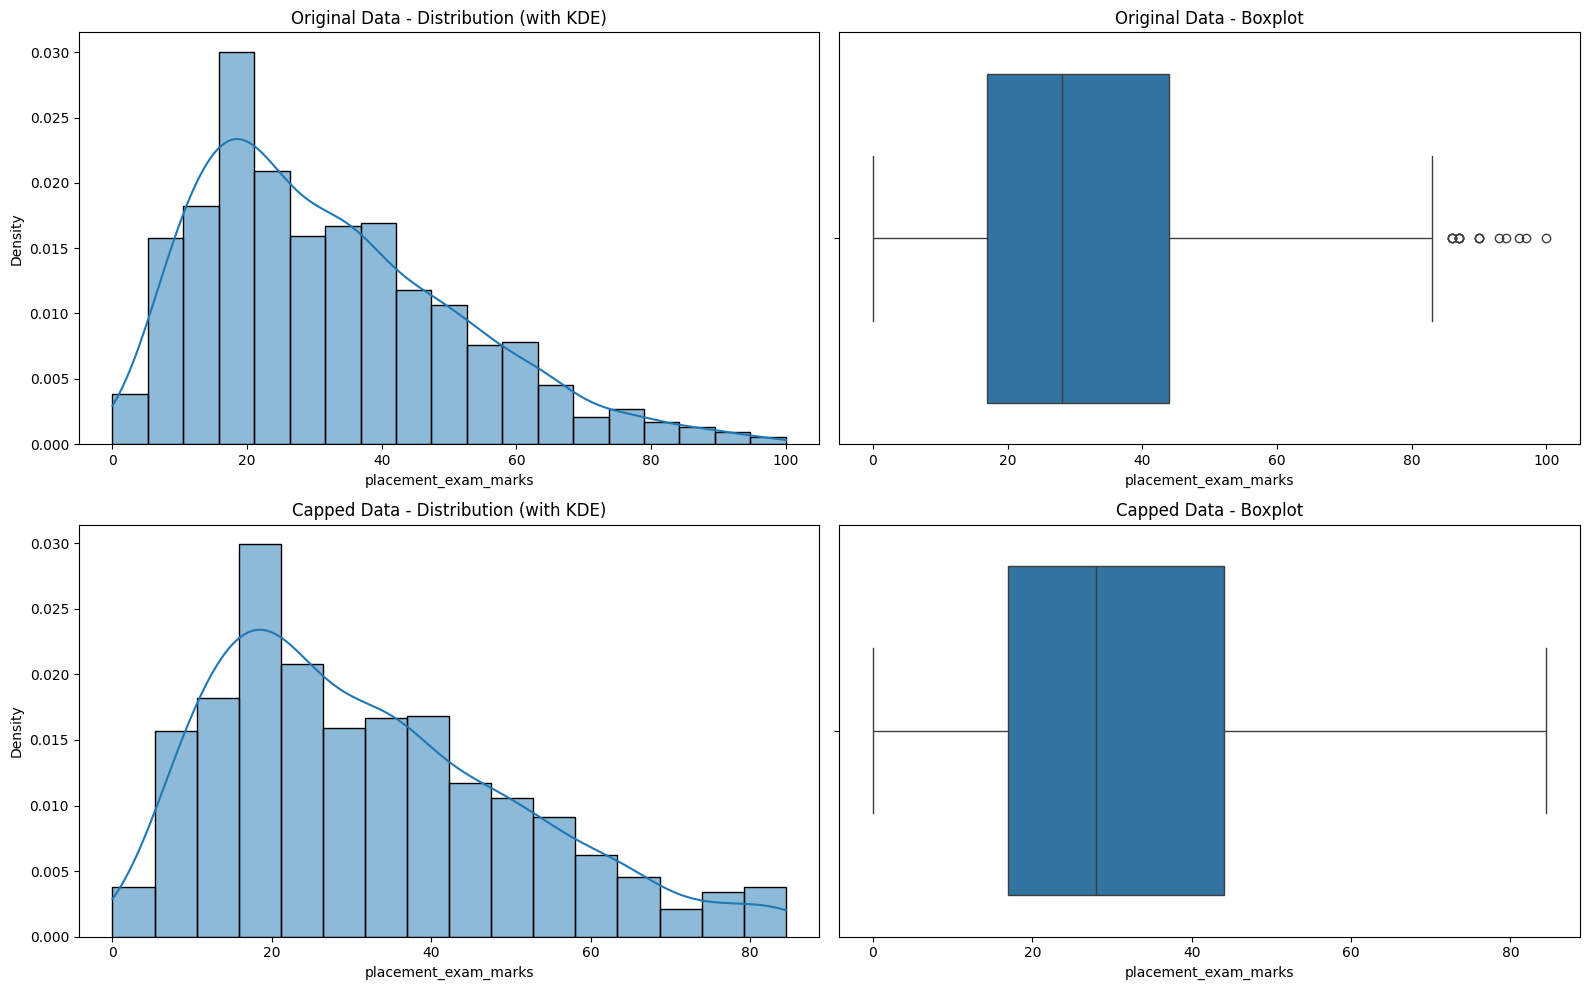

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original Data - Distribution with KDE
sns.histplot(df['placement_exam_marks'], ax=axes[0, 0], stat='density', kde=True)
axes[0, 0].set_title('Original Data - Distribution (with KDE)')

# Original Data - Boxplot
sns.boxplot(x=df['placement_exam_marks'], ax=axes[0, 1])
axes[0, 1].set_title('Original Data - Boxplot')

# Capped Data - Distribution with KDE
sns.histplot(new_df_cap['placement_exam_marks'], ax=axes[1, 0], stat='density', kde=True)
axes[1, 0].set_title('Capped Data - Distribution (with KDE)')

# Capped Data - Boxplot
sns.boxplot(x=new_df_cap['placement_exam_marks'], ax=axes[1, 1])
axes[1, 1].set_title('Capped Data - Boxplot')

plt.tight_layout()
plt.show()